In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cifar10-python/cifar-10-python.tar.gz
/kaggle/input/cifar10-python/cifar-10-batches-py/data_batch_1
/kaggle/input/cifar10-python/cifar-10-batches-py/data_batch_2
/kaggle/input/cifar10-python/cifar-10-batches-py/batches.meta
/kaggle/input/cifar10-python/cifar-10-batches-py/test_batch
/kaggle/input/cifar10-python/cifar-10-batches-py/data_batch_3
/kaggle/input/cifar10-python/cifar-10-batches-py/data_batch_5
/kaggle/input/cifar10-python/cifar-10-batches-py/data_batch_4
/kaggle/input/cifar10-python/cifar-10-batches-py/readme.html


In [2]:
import torch #Core Framework
import torch.nn as nn #Neural Network
import torch.optim as optim #Optimizer
import torchvision #datasets+transforms
import torchvision.transforms as transforms
from torch.utils.data import DataLoader #batching
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [3]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
BATCH_SIZE = 128
EPOCHS = 30
LR = 0.001

In [5]:
# DATA AUGMENTATION
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])


In [6]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)


100%|██████████| 170M/170M [00:01<00:00, 106MB/s]  


In [7]:
print(train_dataset.classes)
print(len(train_dataset.classes))


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
10


In [8]:
from collections import Counter

labels = [label for _, label in train_dataset]
print(Counter(labels))


Counter({6: 5000, 9: 5000, 4: 5000, 1: 5000, 2: 5000, 7: 5000, 8: 5000, 3: 5000, 5: 5000, 0: 5000})


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [10]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            
            
        )
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )
        
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x



    


In [11]:
model=CNN().to(device)

In [12]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [13]:
train_losses = []
train_accuracies = []
val_accuracies = []
learning_rates = []

In [14]:
num_epochs = 30

for epoch in range(num_epochs):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_accuracies.append(val_acc)

    learning_rates.append(optimizer.param_groups[0]["lr"])
    scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Val Acc: {val_acc:.4f}")

Epoch 1/30 | Train Loss: 1.6889 | Train Acc: 0.3762 | Val Acc: 0.5082
Epoch 2/30 | Train Loss: 1.2367 | Train Acc: 0.5533 | Val Acc: 0.6224
Epoch 3/30 | Train Loss: 1.0477 | Train Acc: 0.6274 | Val Acc: 0.6525
Epoch 4/30 | Train Loss: 0.9342 | Train Acc: 0.6724 | Val Acc: 0.7220
Epoch 5/30 | Train Loss: 0.8451 | Train Acc: 0.7080 | Val Acc: 0.7465
Epoch 6/30 | Train Loss: 0.7785 | Train Acc: 0.7345 | Val Acc: 0.7680
Epoch 7/30 | Train Loss: 0.7271 | Train Acc: 0.7532 | Val Acc: 0.7186
Epoch 8/30 | Train Loss: 0.6821 | Train Acc: 0.7681 | Val Acc: 0.7913
Epoch 9/30 | Train Loss: 0.6391 | Train Acc: 0.7852 | Val Acc: 0.7906
Epoch 10/30 | Train Loss: 0.6047 | Train Acc: 0.7957 | Val Acc: 0.8236
Epoch 11/30 | Train Loss: 0.5207 | Train Acc: 0.8271 | Val Acc: 0.8228
Epoch 12/30 | Train Loss: 0.4931 | Train Acc: 0.8359 | Val Acc: 0.8494
Epoch 13/30 | Train Loss: 0.4723 | Train Acc: 0.8440 | Val Acc: 0.8514
Epoch 14/30 | Train Loss: 0.4581 | Train Acc: 0.8480 | Val Acc: 0.8613
Epoch 15/30 | T

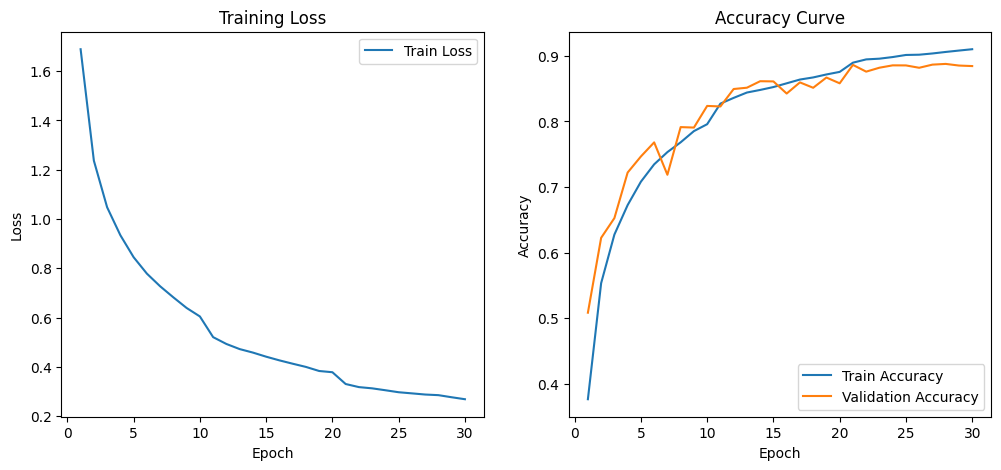

In [15]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [16]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())


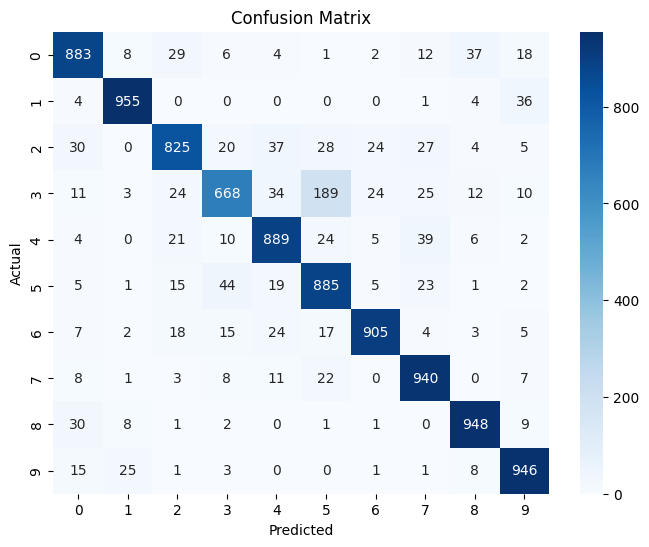

In [17]:
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

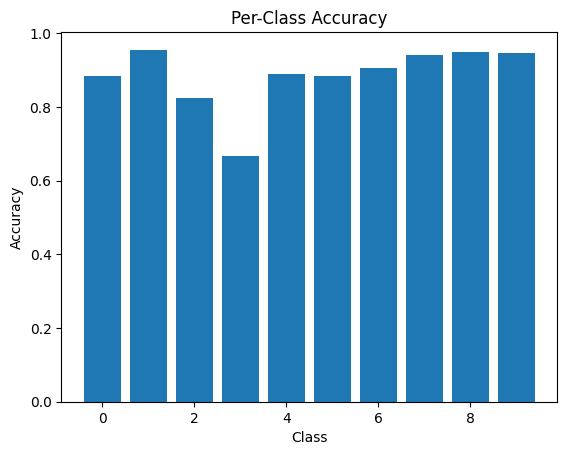

In [18]:
class_acc = cm.diagonal() / cm.sum(axis=1)

plt.bar(range(10), class_acc)
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.show()

In [22]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, class_idx):
        output = self.model(x)

        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = torch.mean(self.gradients, dim=(2,3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1)

        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().detach().numpy()
        cam = cam / cam.max()

        return cam

In [23]:
target_layer = model.conv_layers[14]
gradcam = GradCAM(model, target_layer)

image, label = next(iter(test_loader))
image = image[0].unsqueeze(0).to(device)

cam = gradcam.generate(image, label[0].item())

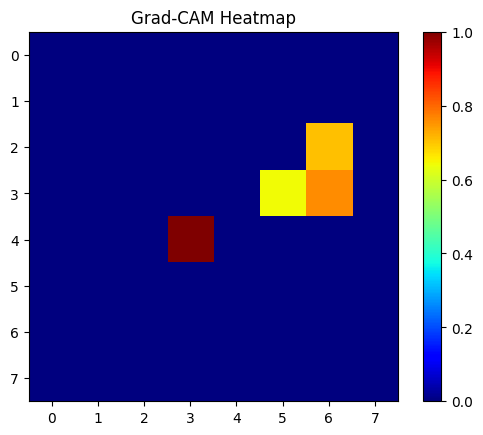

In [24]:
plt.imshow(cam, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.colorbar()
plt.show()

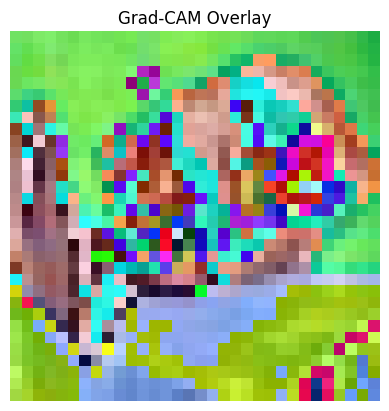

In [25]:
import cv2
import numpy as np

img = image.squeeze().cpu().permute(1,2,0).numpy()

heatmap = cv2.resize(cam, (32,32))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

overlay = heatmap * 0.4 + img * 255

plt.imshow(overlay.astype(np.uint8))
plt.title("Grad-CAM Overlay")
plt.axis("off")
plt.show()

In [27]:
cam = gradcam.generate(image, label[0].item())
img = image.squeeze().cpu().permute(1,2,0).numpy()
import cv2
import numpy as np

heatmap = cv2.resize(cam, (32,32))
heatmap = np.uint8(255 * heatmap)
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
overlay = heatmap_color * 0.4 + img * 255
overlay = overlay.astype(np.uint8)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8980392..1.0].


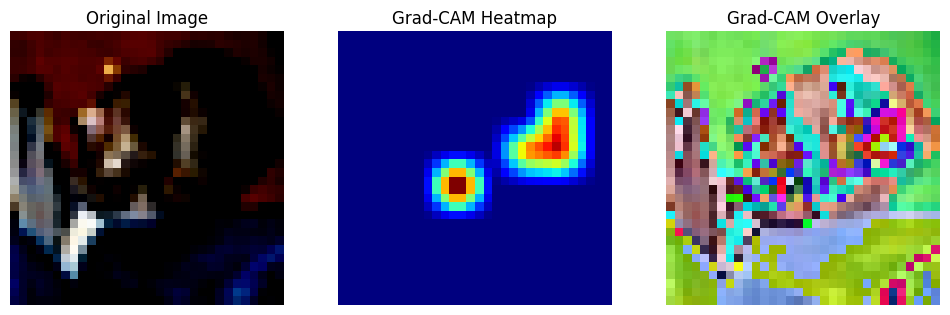

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Original image
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

# Grad-CAM heatmap
plt.subplot(1,3,2)
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")

# Overlay
plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.show()

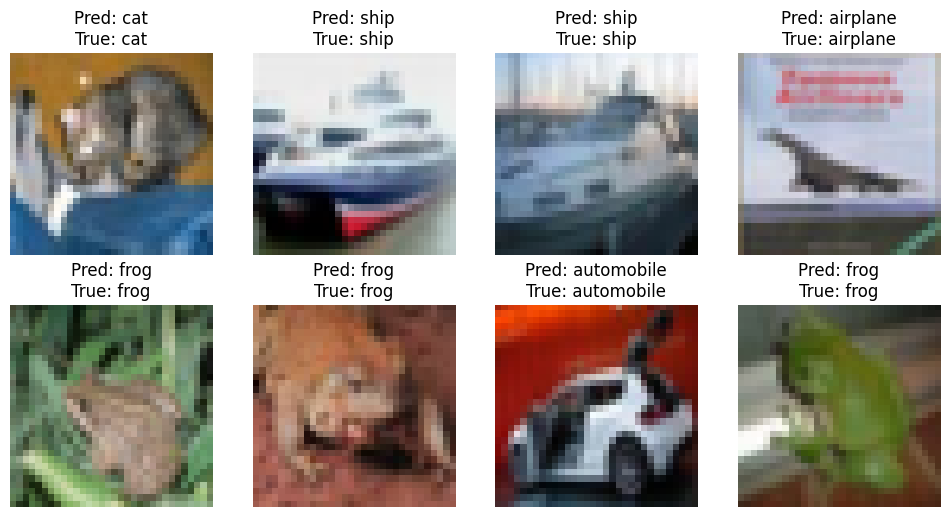

In [26]:
import numpy as np

classes = test_dataset.classes

model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    img = images[i] / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.title(f"Pred: {classes[preds[i]]}\nTrue: {classes[labels[i]]}")
    plt.axis("off")

plt.show()
